In [38]:
import pytensor, os
print("PYTENSOR_FLAGS:", os.environ.get("PYTENSOR_FLAGS"))
print("cxx:", pytensor.config.cxx)
print("PATH has ucrt64:", "C:/msys64/ucrt64/bin" in os.environ["PATH"].replace("\\", "/"))

PYTENSOR_FLAGS: cxx=C:/msys64/ucrt64/bin/g++.exe,base_compiledir=C:/pytensor_cache,mode=FAST_RUN
cxx: C:/msys64/ucrt64/bin/g++.exe
PATH has ucrt64: True


In [39]:
import pytensor
import pytensor.tensor as pt

x = pt.scalar()
f = pytensor.function([x], x + 1)
print(f(2.0))

3.0


In [40]:
import pytensor
print("PYTENSOR_FLAGS:", __import__("os").environ.get("PYTENSOR_FLAGS"))
print("cxx:", pytensor.config.cxx)

PYTENSOR_FLAGS: cxx=C:/msys64/ucrt64/bin/g++.exe,base_compiledir=C:/pytensor_cache,mode=FAST_RUN
cxx: C:/msys64/ucrt64/bin/g++.exe


In [41]:
import sys
print(sys.version)
print(sys.executable)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
c:\Users\C.Price\Habnetic\resilient-housing-bayes\.venv\Scripts\python.exe


# RTM — Phase 1b: Bayesian Logistic Inference (v1b)

Model:

logit(p_i) = α + β_E * E_std_i + β_H * H_std_i  
Y_i ~ Bernoulli(p_i)

Goal:
- Recover synthetic parameters
- Validate inference stability
- Compute posterior ranking metrics

## 0) Setup

In [42]:
from __future__ import annotations

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# Resolve repo root
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name.lower() == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

assert (REPO_ROOT / "src").exists()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.rtm.io_hazard import load_rtm_pluvial_v1_buildings

VERSION = "v1c"   # "v1b" (baseline sensitivity) or "v1c" (structural sensitivity)
SCENARIO = "bE02_bH06"  # v1b: "p02"|"p05"|"p10"  |  v1c: "bE10_bH06"|"bE10_bH02"|"bE02_bH06"

OUT_DIR = REPO_ROOT / "outputs" / "rtm" / f"inference_{VERSION}" / SCENARIO
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("VERSION:", VERSION, "SCENARIO:", SCENARIO)
print("OUT_DIR:", OUT_DIR)

print("Repo root:", REPO_ROOT)

Repo root: C:\Users\C.Price\Habnetic\resilient-housing-bayes
VERSION: v1c SCENARIO: bE02_bH06
OUT_DIR: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\inference_v1c\bE02_bH06
Repo root: C:\Users\C.Price\Habnetic\resilient-housing-bayes


## 1) Load outcome + inputs

In [43]:
# --- Load outcome ---
# --- Load outcome ---
Y_PATH = REPO_ROOT / "outputs" / "rtm" / "outcomes" / f"Y_damage_{VERSION}_{SCENARIO}.parquet"
assert Y_PATH.exists(), f"Outcome file missing: {Y_PATH}"
Y_df = pd.read_parquet(Y_PATH)

# Normalize outcome column name
if "Y_damage_v1b" in Y_df.columns:
    y_col = "Y_damage_v1b"
elif "Y_damage" in Y_df.columns:
    y_col = "Y_damage"
else:
    raise KeyError(f"Outcome column missing. Found columns: {list(Y_df.columns)}")

print("Using outcome column:", y_col)

# --- Load exposure ---
E_PATH = REPO_ROOT / "outputs" / "rtm" / "water_exposure_Ehat_v0.parquet"
E_df = pd.read_parquet(E_PATH)[["bldg_id", "E_hat"]]

# --- Load hazard ---
haz_df = load_rtm_pluvial_v1_buildings()

# --- Merge full dataset ---
df_full = Y_df.merge(E_df, on="bldg_id", validate="one_to_one")
df_full = df_full.merge(haz_df, on="bldg_id", validate="one_to_one")

print("Full rows:", len(df_full))

# --- Subsample for inference ---
N = 5000
df = df_full.sample(N, random_state=42).reset_index(drop=True)

print("Subsample rows:", len(df))
df.head()

Using outcome column: Y_damage
Full rows: 221324
Subsample rows: 5000


,bldg_id,Y_damage,p_true,outcome_src,outcome_version,seed,p0_baseline,alpha,beta_E,beta_H,E_hat,H_pluvial_v1_mm
0,754660,0,0.029274,synthetic,v1c_bE02_bH06,42,0.05,-2.944439,0.2,0.6,0.352021,25.460167
1,1089288,0,0.068635,synthetic,v1c_bE02_bH06,42,0.05,-2.944439,0.2,0.6,0.265809,25.757582
2,181051,0,0.043091,synthetic,v1c_bE02_bH06,42,0.05,-2.944439,0.2,0.6,0.452870,25.582821
3,1060547,0,0.064442,synthetic,v1c_bE02_bH06,42,0.05,-2.944439,0.2,0.6,-0.326680,25.781500
4,1027296,0,0.065126,synthetic,v1c_bE02_bH06,42,0.05,-2.944439,0.2,0.6,0.367937,25.731373


## 2) Standardize predictors

In [44]:
def zscore(x: pd.Series) -> pd.Series:
    mu = x.mean()
    sd = x.std(ddof=1)
    return (x - mu) / sd

df["E_std"] = zscore(df["E_hat"])
df["H_std"] = zscore(df["H_pluvial_v1_mm"])

print("E_std mean/std:", df["E_std"].mean(), df["E_std"].std(ddof=1))
print("H_std mean/std:", df["H_std"].mean(), df["H_std"].std(ddof=1))

E_std mean/std: 2.842170943040401e-18 1.0
H_std mean/std: -5.561066e-06 0.99999994


## 3) Bayesian Logistic Model

In [45]:
import pymc as pm, sys
print("PyMC:", pm.__version__)
print("Python:", sys.version)
print("Has Data:", hasattr(pm, "Data"))
print("Has ConstantData:", hasattr(pm, "ConstantData"))
print("Executable:", sys.executable)

PyMC: 5.28.1
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Has Data: True
Has ConstantData: False
Executable: c:\Users\C.Price\Habnetic\resilient-housing-bayes\.venv\Scripts\python.exe


In [46]:
coords = {"obs_id": np.arange(len(df))}

with pm.Model(coords=coords) as model:
    E_data = pm.Data("E_std", df["E_std"].to_numpy(), dims="obs_id")
    H_data = pm.Data("H_std", df["H_std"].to_numpy(), dims="obs_id")

    alpha  = pm.Normal("alpha", 0, 2.5)
    beta_E = pm.Normal("beta_E", 0, 2.5)
    beta_H = pm.Normal("beta_H", 0, 2.5)

    logit_p = alpha + beta_E * E_data + beta_H * H_data
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p), dims="obs_id")

    pm.Bernoulli(
        "Y_obs",
        logit_p=logit_p,
        observed=df[y_col].to_numpy(),
        dims="obs_id",
    )

    idata = pm.sample(
        draws=500,
        tune=500,
        chains=2,
        cores=1,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True,
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta_E, beta_H]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


## 4) Convergence Diagnostics

In [47]:
az.summary(idata, var_names=["alpha", "beta_E", "beta_H"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-2.956,0.070,-3.095,-2.840,0.002,0.002,778.0,785.0,1.0
beta_E,0.064,0.069,-0.078,0.186,0.002,0.002,816.0,740.0,1.0
beta_H,0.570,0.049,0.477,0.662,0.002,0.002,586.0,740.0,1.0


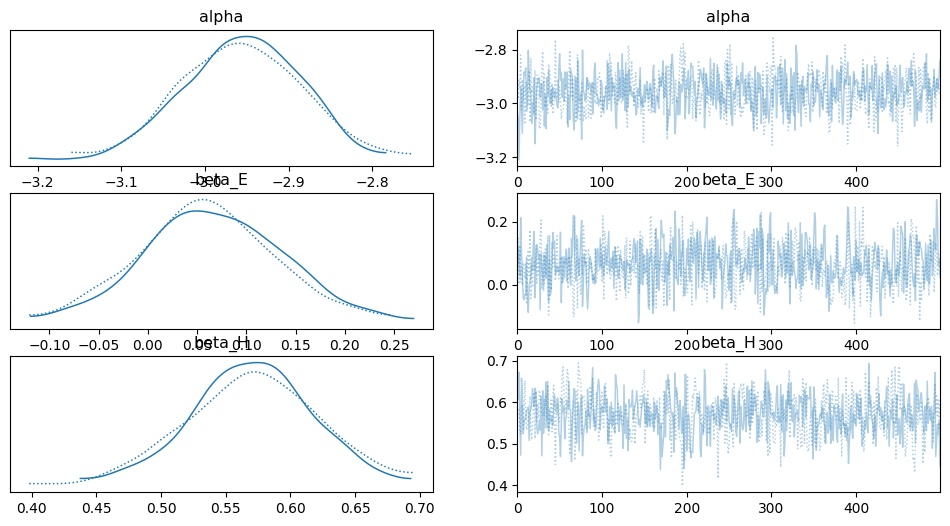

In [48]:
az.plot_trace(idata, var_names=["alpha", "beta_E", "beta_H"])
plt.show()

## 5) Posterior Predictive Check

Sampling: [Y_obs]


Output()

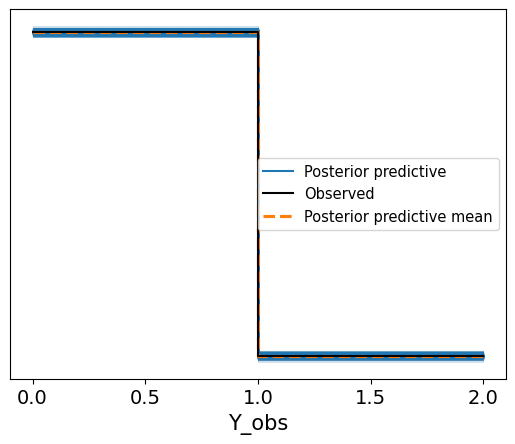

In [49]:
with model:
    ppc = pm.sample_posterior_predictive(idata, random_seed=42)

az.plot_ppc(ppc)
plt.show()

## 6) Posterior Ranking Metrics

In [50]:
# Posterior mean probability per building
p_post = idata.posterior["p"].mean(dim=("chain", "draw")).values

df["p_post_mean"] = p_post

# Rank by posterior mean
df["rank_post_mean"] = df["p_post_mean"].rank(ascending=False)

df.head()

,bldg_id,Y_damage,p_true,outcome_src,outcome_version,seed,p0_baseline,alpha,beta_E,beta_H,E_hat,H_pluvial_v1_mm,E_std,H_std,p_post_mean,rank_post_mean
0,754660,0,0.029274,synthetic,v1c_bE02_bH06,42,0.05,-2.944439,0.2,0.6,0.352021,25.460167,0.420016,-1.076007,0.028271,4653.0
1,1089288,0,0.068635,synthetic,v1c_bE02_bH06,42,0.05,-2.944439,0.2,0.6,0.265809,25.757582,0.317658,0.425097,0.063458,1234.0
2,181051,0,0.043091,synthetic,v1c_bE02_bH06,42,0.05,-2.944439,0.2,0.6,0.452870,25.582821,0.539750,-0.456951,0.039980,2780.0
3,1060547,0,0.064442,synthetic,v1c_bE02_bH06,42,0.05,-2.944439,0.2,0.6,-0.326680,25.781500,-0.385785,0.545816,0.064900,1176.0
4,1027296,0,0.065126,synthetic,v1c_bE02_bH06,42,0.05,-2.944439,0.2,0.6,0.367937,25.731373,0.438912,0.292816,0.059570,1417.0


In [51]:
# Top-k membership probability
k = 1000  # top 1000 buildings

p_samples = idata.posterior["p"].stack(sample=("chain", "draw")).values

topk_counts = np.zeros(len(df))

for s in range(p_samples.shape[1]):
    idx = np.argsort(-p_samples[:, s])[:k]
    topk_counts[idx] += 1

topk_prob = topk_counts / p_samples.shape[1]

df["topk_prob"] = topk_prob

print("Top-k probability summary:")
df["topk_prob"].describe()

Top-k probability summary:


count    5000.000000
mean        0.200000
std         0.389837
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: topk_prob, dtype: float64

In [52]:
# --- Save idata to disk ---

INF_DIR = REPO_ROOT / "outputs" / "rtm" / "inference"
INF_DIR.mkdir(parents=True, exist_ok=True)

idata_path = INF_DIR / f"rtm_damage_{VERSION}_{SCENARIO}_logistic_idata.nc"
az.to_netcdf(idata, idata_path)

print("Saved idata to:", idata_path)

Saved idata to: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\inference\rtm_damage_v1c_bE02_bH06_logistic_idata.nc


In [53]:
import arviz as az
idata = az.from_netcdf(idata_path)
az.summary(idata, var_names=["alpha", "beta_E", "beta_H"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-2.956,0.070,-3.095,-2.840,0.002,0.002,778.0,785.0,1.0
beta_E,0.064,0.069,-0.078,0.186,0.002,0.002,816.0,740.0,1.0
beta_H,0.570,0.049,0.477,0.662,0.002,0.002,586.0,740.0,1.0


## 7) Save Decision Metrics

In [54]:
decision_out = df[
    ["bldg_id", "p_post_mean", "rank_post_mean", "topk_prob"]
].copy()

out_path   = OUT_DIR / f"decision_metrics_{VERSION}_{SCENARIO}.parquet"
decision_out.to_parquet(out_path, index=False)

print("Saved:", out_path)

Saved: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\inference_v1c\bE02_bH06\decision_metrics_v1c_bE02_bH06.parquet


In [55]:
print(df["outcome_version"].unique())
print(df["p0_baseline"].unique())
print(df["alpha"].unique())

<ArrowStringArray>
['v1c_bE02_bH06']
Length: 1, dtype: str
[0.05]
[-2.94443898]
